In [1]:
import pandas as pd

In [5]:
df = pd.read_csv("/content/iris.data.csv" , names = ['Sepal length', 'Sepal width', 'Petal length', 'Petal width', 'Species'])
df.head()

,Sepal length,Sepal width,Petal length,Petal width,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
df.shape

(150, 5)

This dataset has 150 rows and 5 columns

In [7]:
new_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

In [8]:
df.columns = new_cols

In [9]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [10]:
df.dtypes

,0
sepal_length,float64
sepal_width,float64
petal_length,float64
petal_width,float64
species,object


other than species every column is float

In [11]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


Sepel Length
- has the values ranging from 4.3 - 7.9, with the mean/avarage of 5.84 which is closer the meadian (50%), this is expected to be symetric.



# Sepal Lenght

<Axes: ylabel='Frequency'>

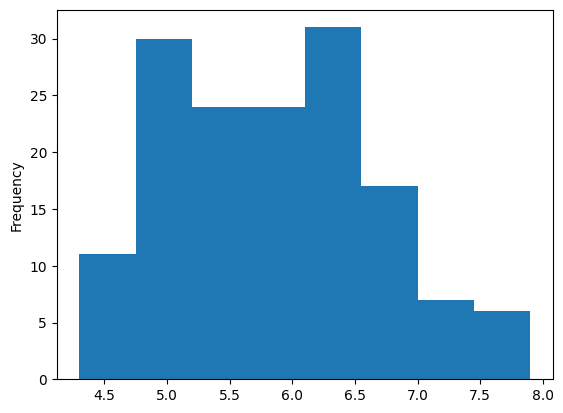

In [19]:
df["sepal_length"].plot(kind="hist" , bins=8)

It's look like the bell curve, but the there much low data to determine exact the shape of the distribution.

In [20]:
df_sepal = df[["sepal_length"]]

<Axes: >

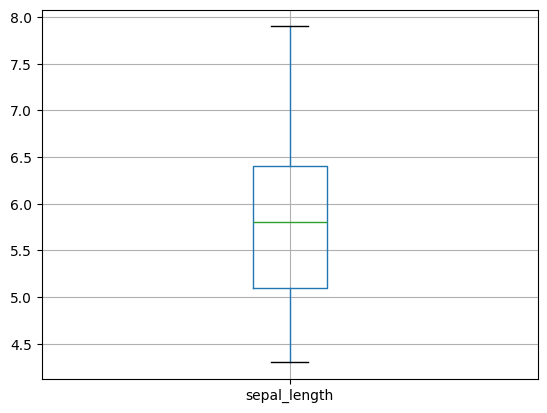

In [22]:
df.boxplot(column=["sepal_length"])

In [25]:
ds = df_sepal.describe()

In [38]:
per_25 = ds.loc["25%"].values[0]
per_75 = ds.loc["75%"].values[0]
iqr = per_75 - per_25
iqr

np.float64(1.3000000000000007)

In [39]:
def is_outlier(x):
  if x < (per_25 - 1.5 * iqr) or x > (per_75 + 1.5 * iqr):
    return True
  else:
    return False

In [41]:
df_sepal["is_outlier"] = df["sepal_length"].apply(
    is_outlier
)
df_sepal.value_counts("is_outlier")

/tmp/ipykernel_9843/1177707698.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sepal["is_outlier"] = df["sepal_length"].apply(


,count
is_outlier,
False,150


there is not outliers detected accoridng 1.5* IRQ method.

#Bivariate Analysis

<Axes: xlabel='sepal_length', ylabel='sepal_width'>

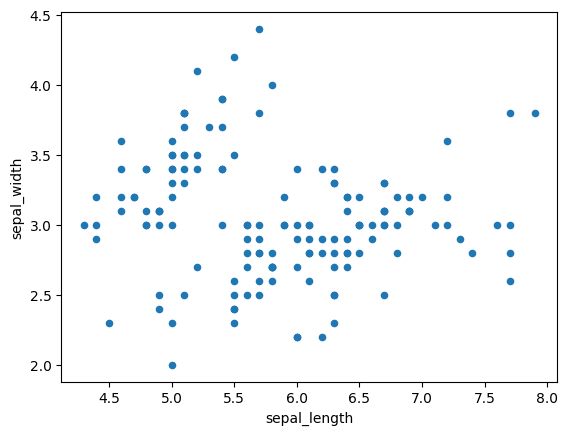

In [44]:
df[["sepal_length", "sepal_width"]].plot(
    kind="scatter" , x ="sepal_length" , y = "sepal_width"
)

there is positive and week correlation

In [46]:
#plot correlation

corr = df[["sepal_length", "petal_length", "sepal_width", "petal_width" ]].corr()

In [47]:
corr

,sepal_length,petal_length,sepal_width,petal_width
sepal_length,1.000000,0.871754,-0.109369,0.817954
petal_length,0.871754,1.000000,-0.420516,0.962757
sepal_width,-0.109369,-0.420516,1.000000,-0.356544
petal_width,0.817954,0.962757,-0.356544,1.000000


<Axes: >

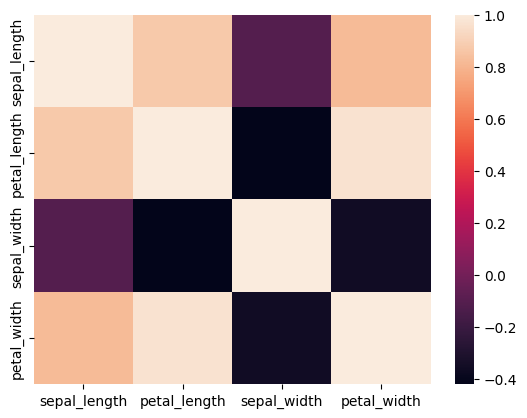

In [48]:
#correlation heatmap

import seaborn as sns

sns.heatmap(corr)


In [49]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [50]:
# fit a model to pedict species

In [51]:
#train and test split
from sklearn.model_selection import train_test_split

X = df.drop("species", axis=1)
y = df["species"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [52]:
#naivebays
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(X_train, y_train)

#training score
model.score(X_train, y_train)

0.95

In [53]:
#confusion matrix
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
cm

array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]])

In [54]:
#classifcation report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [57]:
from sklearn.model_selection import train_test_split

selected_cols = ["sepal_length" ,	"sepal_width"	,"petal_width"]

df_new = df[ selected_cols  + ["species"]]

X = df_new.drop("species", axis=1)
y = df_new["species"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#naivebays
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(X_train, y_train)

#training score
print(model.score(X_train, y_train))

from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)

#classifcation report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

0.9333333333333333
[[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.89      0.94         9
 Iris-virginica       0.92      1.00      0.96        11

       accuracy                           0.97        30
      macro avg       0.97      0.96      0.97        30
   weighted avg       0.97      0.97      0.97        30



In [58]:
from sklearn.model_selection import train_test_split

selected_cols = ["sepal_length" ,	"sepal_width"	]

df_new = df[ selected_cols  + ["species"]]

X = df_new.drop("species", axis=1)
y = df_new["species"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#naivebays
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(X_train, y_train)

#training score
print(model.score(X_train, y_train))

from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)

#classifcation report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

0.775
[[10  0  0]
 [ 0  7  2]
 [ 0  1 10]]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.88      0.78      0.82         9
 Iris-virginica       0.83      0.91      0.87        11

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30

